# 08 · Did the loyalty rollout work? — difference-in-differences (CausalPy)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The business decision.** We launched the loyalty app in some stores, not others. Revenue in the
launch stores went up — but revenue went up *everywhere* (a seasonal tide lifts all boats). Did the app
add anything **net of that tide**, and is it worth rolling out to the whole chain?

### The idea: two differences

**Difference-in-differences (DiD)** is the workhorse of quasi-experiments. It takes **two** differences
and subtracts them:

$$\text{DiD} = \underbrace{(\bar Y^{\text{treated}}_{\text{after}} - \bar Y^{\text{treated}}_{\text{before}})}_{\text{treated change}} - \underbrace{(\bar Y^{\text{control}}_{\text{after}} - \bar Y^{\text{control}}_{\text{before}})}_{\text{control change}}.$$

The first difference (treated after − before) contains the app effect **plus** the seasonal tide; the
second (control after − before) is the tide **alone**. Subtracting removes the tide and leaves the app
effect. It's the same "compare like with like" logic as everywhere else, applied *across time*.

### The one assumption everything rests on: parallel trends

DiD is valid only if, **absent the app**, treated and control stores would have moved *in parallel* — the
control's change is a fair stand-in for what the treated stores' change would have been. This is untestable
after launch (we never see the treated stores' no-app future), but the **pre-launch trends are the
evidence**: if the two groups moved together *before* the app, parallel trends is credible. We check this
with an **event study** (the effect period-by-period) and falsify with a **placebo** (a fake
launch date in the pre-period, which should show ≈ 0 effect).

> **On real data.** Swap in your **own store/region panel** — one row per store per period with revenue, a
> treated/control flag, and a period index. The textbook public example is **Card & Krueger (1994)** on
> minimum wage and employment (fast-food restaurants in New Jersey vs Pennsylvania). One warning we
> *demonstrate live* in Step 7: if stores adopt at **different times** ("staggered rollout"), naive DiD can
> be badly biased and you need modern estimators (Callaway–Sant'Anna, Sun–Abraham).

It follows the repo's fixed **7-step contract**: question → simulate → identify → estimate → validate → decide in € → caveats.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import causalpy as cp
from cmp import dgp, estimators as est, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 23; LAUNCH = 12; TRUE = 400.0

## 2 · Simulate a ground truth

40 stores, half get the loyalty app at week 12. Every store shares a seasonal pattern and has its
own baseline; the app adds a **true €400/store/week**. Treated and control move in **parallel**
before launch by construction — so DiD should recover €400, and the event study should show a flat
pre-trend.

**The data-generating model** — exactly what `dgp.did_rollout` implements (defaults & seed in
`src/cmp/dgp.py`). Stores $s = 1,\dots,40$ (a random half treated, $D_s = 1$), weeks
$t = 0,\dots,23$, launch at week 12:

$$
Y_{st} = \underbrace{\alpha_s}_{\text{store baseline}}
  + \underbrace{60\sin\!\big(\tfrac{2\pi t}{12}\big)}_{\text{shared season}}
  + \underbrace{400\; D_s\, \mathbf 1[t \ge 12]}_{\text{true effect}}
  + \varepsilon_{st},
\qquad \alpha_s \sim \mathcal N(1000,\, 150^{2}),\;\;
\varepsilon_{st} \sim \mathcal N(0,\, 80^{2}).
$$

**Parallel trends holds by construction**: the seasonal term is *identical* across stores (no
store-specific loading on it) and $\alpha_s$ is time-invariant, so absent the app the treated and
control means move in lockstep — exactly what the event study's flat pre-trend should (and does)
show. This is the assumption the caveats section then breaks on purpose (staggered adoption) to
demonstrate the two-way fixed-effects (TWFE) trap.


In [2]:
df, true_effect = dgp.did_rollout(n_stores=40, n_weeks=24, launch_week=LAUNCH, true_effect=TRUE, seed=SEED)
print(f"TRUE effect = €{true_effect:.0f}/store/week  ·  {df['unit'].nunique()} stores, {df['t'].nunique()} weeks, launch week {LAUNCH}")
df.head()

TRUE effect = €400/store/week  ·  40 stores, 24 weeks, launch week 12


,store,unit,t,week,group,post_treatment,post,revenue
0,store_00,0,0,0,1,False,0,1071.613014
1,store_00,0,1,1,1,False,0,1066.597066
2,store_00,0,2,2,1,False,0,1019.187212
3,store_00,0,3,3,1,False,0,834.246887
4,store_00,0,4,4,1,False,0,1030.278745


## 3 · Identify — the estimand, and the two assumptions that buy it

**The estimand, precisely.** Store $s$ in week $t$ has two *potential* revenues: $Y_{st}(1)$ with the
app and $Y_{st}(0)$ without — we only ever observe one of them. With $D_s \in \{0,1\}$ flagging the
pilot stores and $t_0$ the launch week, DiD targets the **ATT**, the average treatment effect *on the
treated stores, after launch*:

$$\text{ATT} \;=\; \mathbb{E}\big[\,Y_{st}(1)-Y_{st}(0)\;\big|\;D_s=1,\ t\ge t_0\big].$$

The second term inside is the counterfactual we never see — what the pilot stores *would have* earned
post-launch without the app. Note the final **T**: this is the effect *on the pilot stores*, not on the
whole chain; it need not equal what the other stores would experience (pilot sites are rarely picked at
random), which is exactly why Step 6 stress-tests the transfer before scaling to 500 stores. Two named
assumptions let the control stores stand in for the missing counterfactual:

**Assumption 1 — Parallel trends (PT)**, stated on *untreated* potential outcomes: for any post-launch
week $t$ and pre-launch week $t'$,

$$\mathbb{E}\big[Y_{st}(0)-Y_{st'}(0)\,\big|\,D_s{=}1\big] \;=\; \mathbb{E}\big[Y_{st}(0)-Y_{st'}(0)\,\big|\,D_s{=}0\big],\qquad t\ge t_0 > t'.$$

In words: had the app never launched, the pilot stores' revenue would have *changed* by the same amount
as the controls'. **Levels may differ freely** — pilot stores can be systematically bigger, busier,
richer; it is the *changes* that must match. In marketing terms: the seasonal tide, chain-wide
promotions and macro shocks hit both groups alike, and nothing *time-varying and group-specific* (a
regional campaign running only in pilot cities, say) is in play.

**Assumption 2 — No anticipation (NA):**

$$\mathbb{E}\big[\,Y_{st}(1)-Y_{st}(0)\;\big|\;D_s=1\big] \;=\; 0 \qquad \text{for all } t<t_0,$$

i.e. the app moves nothing before it exists. Sounds vacuous; isn't. Pre-launch buzz marketing, staff
trained weeks early, or customers *deferring* purchases until the app's perks arrive all violate it —
and they contaminate the very "before" baseline that DiD subtracts. Step 7 breaks this assumption on
purpose so you can see what the damage looks like.

**Why DiD = ATT — the one-line derivation.** Take the treated group's observed before→after change and
split it, using NA (the treated pre-period observation *is* $Y(0)$), into effect plus counterfactual
trend:

$$\bar Y^{1}_{\text{post}}-\bar Y^{1}_{\text{pre}} \;=\; \underbrace{\text{ATT}}_{\text{what we want}} \;+\; \underbrace{\mathbb{E}\big[Y_{st}(0)-Y_{st'}(0)\,\big|\,D_s{=}1\big]}_{\text{counterfactual trend}}.$$

PT says that trend equals the *control* group's observed change $\bar Y^{0}_{\text{post}}-\bar
Y^{0}_{\text{pre}}$. Subtract it:

$$\text{DiD} \;=\; \big(\bar Y^{1}_{\text{post}}-\bar Y^{1}_{\text{pre}}\big)-\big(\bar Y^{0}_{\text{post}}-\bar Y^{0}_{\text{pre}}\big) \;=\; \text{ATT}.$$

That is the entire method: two assumptions in, one subtraction out.

**The regression forms you'll meet.** The 2×2 DiD is the interaction coefficient $\beta_3$ in
$Y=\beta_0+\beta_1\,\text{group}+\beta_2\,\text{post}+\beta_3\,(\text{group}\times\text{post})+\varepsilon$
— the version we fit in Step 4. Its dynamic cousin, the **event-study regression**, estimates one
effect per week relative to launch:

$$Y_{st}\;=\;\alpha_s+\lambda_t+\sum_{k\neq -1}\beta_k\,\mathbf 1[t-t_0=k]\,D_s+\varepsilon_{st},$$

with store fixed effects $\alpha_s$, common week effects $\lambda_t$, normalized at $k=-1$. The
nonparametric per-week treated−control gap we plot below *is* this regression's $\beta_k$ in the
balanced two-group case — same picture, so you can map our plot onto any paper's event study. The
**leads** ($k<0$) test NA directly and make PT *credible*; nothing can test PT itself post-launch (we
never observe the treated stores' no-app future).

**What the DAG buys us.** Contrast with notebook 01: backdoor adjustment needs the confounder
*measured* so you can condition on it. DiD strikes a different bargain — the store-level confounder
$\alpha_s$ (location, size, clientele: whatever drives both "chosen as pilot" *and* revenue) may stay
**unobserved**, provided it is *time-invariant*: differencing each group against its own past removes
$\alpha_s$, and subtracting the control change removes the common shocks $\lambda_t$. What survives
both subtractions is precisely what PT rules out: time-varying, group-specific shocks.

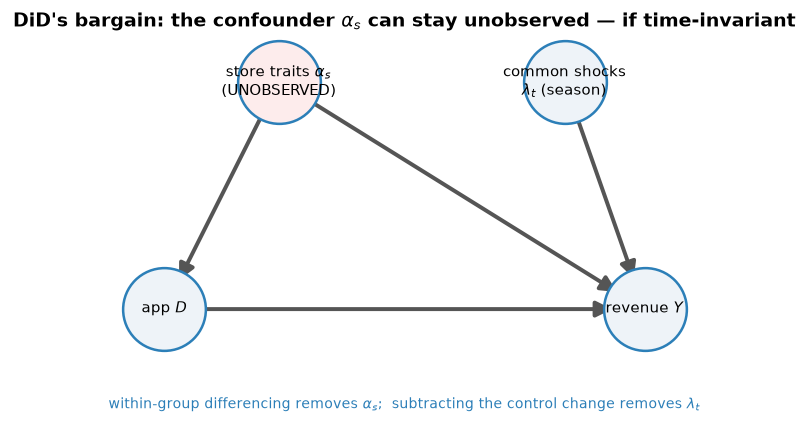

In [3]:
fig, ax = plt.subplots(figsize=(6.0, 3.4))
n_alpha = "store traits $\\alpha_s$\n(UNOBSERVED)"
n_lam   = "common shocks\n$\\lambda_t$ (season)"
n_d, n_y = "app $D$", "revenue $Y$"
pos = {n_alpha: (0.28, 1.0), n_lam: (0.78, 1.0), n_d: (0.08, 0.22), n_y: (0.92, 0.22)}
edges = [(n_alpha, n_d), (n_alpha, n_y), (n_lam, n_y), (n_d, n_y)]
plots.draw_dag(ax, pos, edges, node_colors={n_alpha: "#fdecec"},
               title="DiD's bargain: the confounder $\\alpha_s$ can stay unobserved — if time-invariant")
ax.text(0.5, -0.12, "within-group differencing removes $\\alpha_s$;  subtracting the control change removes $\\lambda_t$",
        ha="center", fontsize=8, color=plots.BLUE)
fig.tight_layout()

Pre-launch leads scatter around 0 within their 90% bands (0 of 12 exclude 0):
  mean |gap| €22, on the order of the per-week noise SE €57 —
  consistent with parallel trends, not a pre-trend.
  (Centred leads average exactly 0 by construction, so it is their SPREAD vs
  the noise band, not a mean, that carries the evidence.)
  Post-launch gaps jump to ≈€400.


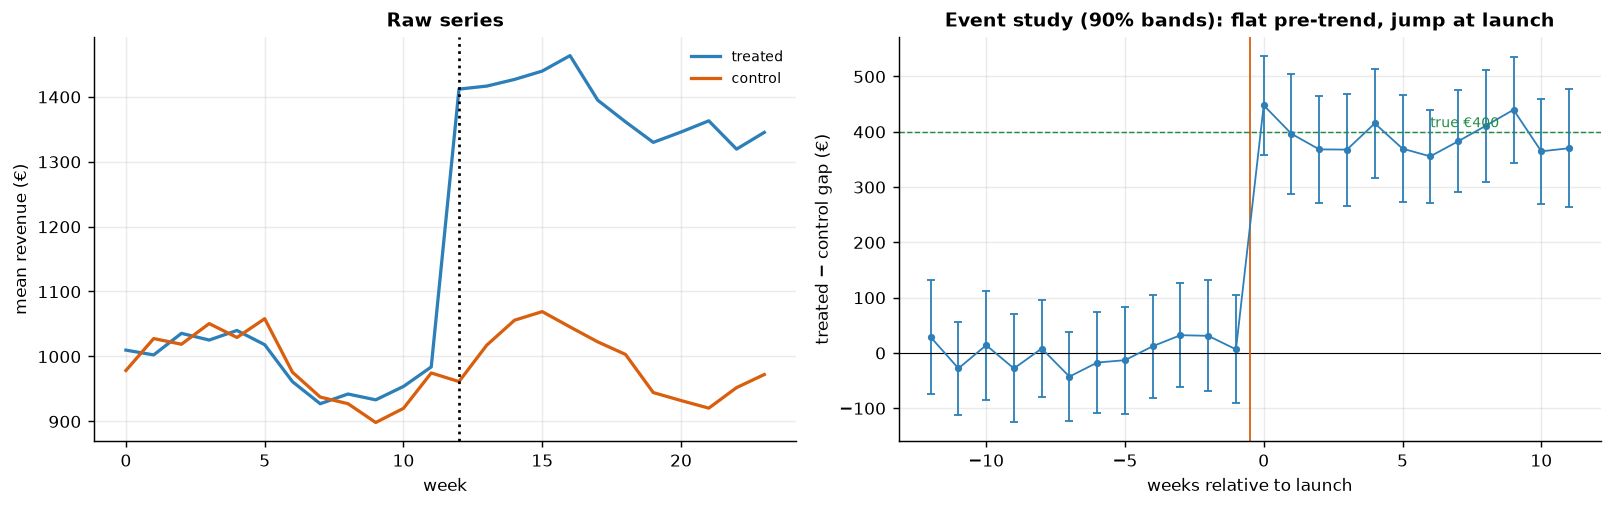

In [4]:
# event study WITH uncertainty: per-week treated−control gap ± 90% band, recentred on the pre-launch mean.
piv = df.pivot_table(index="t", columns="group", values="revenue", aggfunc="mean")
sd_ = df.pivot_table(index="t", columns="group", values="revenue", aggfunc="std")
n_  = df.pivot_table(index="t", columns="group", values="revenue", aggfunc="count")
gap = piv[1] - piv[0]
se  = np.sqrt(sd_[1]**2 / n_[1] + sd_[0]**2 / n_[0])          # SE of each week's treated−control gap
pre = gap.index < LAUNCH
gap_centered = gap - gap[pre].mean()
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
g = df.groupby(["t","group"])["revenue"].mean().unstack()
ax[0].plot(g.index, g[1], color=plots.BLUE, lw=1.8, label="treated"); ax[0].plot(g.index, g[0], color=plots.ORANGE, lw=1.8, label="control")
ax[0].axvline(LAUNCH, color="k", ls=":"); ax[0].set_xlabel("week"); ax[0].set_ylabel("mean revenue (€)"); ax[0].set_title("Raw series"); ax[0].legend(frameon=False, fontsize=8)
ax[1].errorbar(gap_centered.index - LAUNCH, gap_centered.values, yerr=1.645*se.values,
               color=plots.BLUE, marker="o", lw=1.0, ms=3, capsize=2)
ax[1].axhline(0, color="k", lw=0.6); ax[1].axvline(-0.5, color=plots.ORANGE, lw=1)
ax[1].axhline(TRUE, color=plots.GREEN, ls="--", lw=0.8); ax[1].text(6, TRUE+8, f"true €{TRUE:.0f}", fontsize=8, color=plots.GREEN)
ax[1].set_xlabel("weeks relative to launch"); ax[1].set_ylabel("treated − control gap (€)"); ax[1].set_title("Event study (90% bands): flat pre-trend, jump at launch")
fig.tight_layout()
lead_abs = gap_centered[pre].abs().mean(); lead_se = se[pre].mean()
n_out = int((gap_centered[pre].abs() > 1.645 * se[pre]).sum())
print(f"Pre-launch leads scatter around 0 within their 90% bands ({n_out} of {int(pre.sum())} exclude 0):\n"
      f"  mean |gap| €{lead_abs:.0f}, on the order of the per-week noise SE €{lead_se:.0f} —\n"
      f"  consistent with parallel trends, not a pre-trend.\n"
      f"  (Centred leads average exactly 0 by construction, so it is their SPREAD vs\n"
      f"  the noise band, not a mean, that carries the evidence.)\n"
      f"  Post-launch gaps jump to ≈€{TRUE:.0f}.")

**How to read the event study (right panel).** This is the single most important plot in a DiD analysis.
Each dot is the treated-minus-control revenue gap in one week, relative to launch (week 0). Each dot now carries a
**90% uncertainty band**. The story we *want* to see, and do: the pre-launch dots are **flat and their bands
comfortably include zero** — that is the honest content of "parallel trends look credible" (a lead whose band
*excluded* zero would be the red flag), and the assumption the whole method rests on — and then they **jump to ≈ €400 at
launch** and stay there. A rising or falling pre-launch trend would have been a red flag that the two groups
were already diverging, and we'd have had to abandon DiD for synthetic control (notebook 07). The left panel
shows the raw series so you can see both groups riding the same seasonal wave.

## 4 · Estimate — Bayesian difference-in-differences

We now put a number and an interval on that jump. One modeling choice: we first collapse each store's
24 weekly points into a single pre-launch mean and a single post-launch mean. This is primarily the
**Bertrand–Duflo–Mullainathan (2004) serial-correlation guard** — with many periods per unit, DiD
standard errors that ignore within-unit autocorrelation are badly understated, so collapsing to two
periods (pre/post) sidesteps that. It is a modeling decision, not merely an API constraint — though
CausalPy's `DifferenceInDifferences` also happens to consume this classic **2×2 form** cleanly. The
estimate is the `group × post` interaction coefficient $\beta_3$, i.e. the DiD.


**The model behind `est.did`, in symbols.** CausalPy 0.8.1's `LinearRegression` fits, on design row
$\mathbf x_i=(1,\ g_i,\ p_i,\ g_i p_i)^\top$ (intercept, group flag, post flag, interaction; $i$ runs
over the 80 collapsed store-periods — two rows per store):

$$\tilde Y_i \;\sim\; \mathcal N\!\big(\mathbf x_i^\top\boldsymbol\beta,\ \sigma^2\big),\qquad
\beta_j \;\sim\; \mathcal N(0,\ 50^2),\qquad \sigma \;\sim\; \text{HalfNormal}(1),$$

and those priors are **fixed by the library** (verified against the installed source), scaled for data
of order one. On raw euro revenue ($\bar Y\approx$ €1,000, residual spread in the hundreds) a
HalfNormal(1) prior on $\sigma$ is absurdly tight: the prior fights the likelihood and drags the effect
low, with a too-narrow interval around the wrong number. So we fit on **standardized** revenue
$\tilde Y=(Y-\bar Y)/s_Y$ and back-transform only the interaction:

$$\widehat{\text{DiD}}_{\text{€}} \;=\; \beta_3 \cdot s_Y$$

($\bar Y$ is absorbed by the intercept and main effects; the coefficient of a 0/1 interaction only
needs the *scale* $s_Y$ undone). **The general lesson deserves stating as a lesson:** check your
library's default prior scale against your data scale before trusting any fit — defaults tuned for
standardized data will quietly mis-fit raw euros, and the failure mode is a *confident wrong answer*,
not an error message.

In [5]:
agg = df.groupby(["unit","group","post_treatment"])["revenue"].mean().reset_index()
agg["t"] = agg["post_treatment"].astype(int).astype(float)
# CausalPy 0.8.1's LinearRegression ships FIXED priors (beta ~ N(0,50), sigma ~ HalfNormal(1))
# scaled for O(1) data; on revenue ~ €1000 they fight the data and shrink the effect low (and
# too-narrow). We standardize revenue for the fit, then back-transform the effect to euros.
rev_mu, rev_sd = agg["revenue"].mean(), agg["revenue"].std()
agg["revenue_z"] = (agg["revenue"] - rev_mu) / rev_sd
result = est.did(agg, formula="revenue_z ~ 1 + group*post_treatment", fast=FAST)
impact = np.asarray(result.causal_impact).ravel() * rev_sd    # standardized effect -> euros
print(f"DiD effect €{impact.mean():.0f}/store/week (true €{true_effect:.0f})  ·  "
      f"90% credible interval (90% posterior probability the true effect lies inside) "
      f"[€{np.quantile(impact,0.05):.0f}, €{np.quantile(impact,0.95):.0f}]")
print(f"DiD convergence: {est.convergence_report(result.idata)["summary"]}")


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


DiD effect €389/store/week (true €400)  ·  90% credible interval (90% posterior probability the true effect lies inside) [€275, €515]
DiD convergence: max r-hat 1.030 - min ESS 119 - divergences 0


### 4b · Model criticism — the posterior predictive check

Before we *read an effect off* this model, we ask whether it could plausibly have **generated the data
at all**. The 2×2 model is deliberately coarse — four cell means plus one shared Gaussian noise term;
every store baseline $\alpha_s$ it doesn't describe has to live inside that noise. We draw replicated
datasets from the fitted model's posterior predictive, back-transform them to euros, and overlay them
on the 80 observed store-period revenues. If the real distribution (spread, lumpiness, tails) looked
unlike anything the model can produce, no interval downstream would deserve trust. And notice one thing
*because* it foreshadows 5c: for this coarse model to pass, its replicate spread must be **fat** — the
between-store baseline scatter sits in $\sigma$ — and that same fat $\sigma$ is what will make the
effect interval conservative.

PPC: 89% of the 80 observed store-period revenues fall inside their replicate 5–95% band (≈90% if calibrated) — no gross misfit.
Posterior residual σ ≈ €171 — note how fat: it must absorb the between-store baseline spread (sd €150 by construction) that the 4-mean model doesn't describe. 5c shows the price; 5d collects the refund.


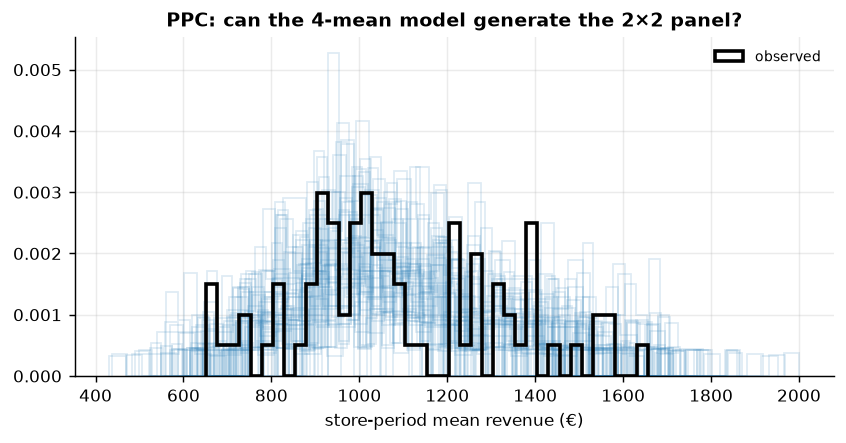

In [6]:
# PPC: replicate the 80 collapsed revenues from the fitted model's posterior predictive (y_hat is
# sampled on the standardized scale, so back-transform each replicate to euros).
yh = result.idata.posterior_predictive["y_hat"]
y_rep_all = (yh.stack(sample=("chain", "draw")).transpose("sample", "obs_ind", "treated_units")
               .values.reshape(-1, len(agg)) * rev_sd + rev_mu)
y_obs = agg["revenue"].values
rng_ppc = np.random.default_rng(0)
y_rep = y_rep_all[rng_ppc.choice(len(y_rep_all), size=min(40, len(y_rep_all)), replace=False)]
fig, ax = plt.subplots(figsize=(6.6, 3.5))
plots.ppc_plot(ax, y_obs, y_rep, title="PPC: can the 4-mean model generate the 2×2 panel?")
ax.set_xlabel("store-period mean revenue (€)"); fig.tight_layout()
lo_ppc = np.quantile(y_rep_all, 0.05, axis=0); hi_ppc = np.quantile(y_rep_all, 0.95, axis=0)
cov_ppc = float(np.mean((y_obs >= lo_ppc) & (y_obs <= hi_ppc)))
sig_eur = float(result.idata.posterior["y_hat_sigma"].mean()) * rev_sd
verdict = "no gross misfit" if 0.82 <= cov_ppc <= 0.98 else "a possible misfit — inspect the tails"
print(f"PPC: {cov_ppc:.0%} of the 80 observed store-period revenues fall inside their replicate 5–95% band "
      f"(≈90% if calibrated) — {verdict}.")
print(f"Posterior residual σ ≈ €{sig_eur:.0f} — note how fat: it must absorb the between-store baseline spread "
      f"(sd €150 by construction) that the 4-mean model doesn't describe. 5c shows the price; 5d collects the refund.")

## 5 · Validate — 2×2 cross-check and the placebo pair

Cross-check the Bayesian estimate against the hand-computed 2×2. With revenue **standardized** before
the fit (so CausalPy's default O(1)-scaled priors don't shrink a €400 effect sitting on €1000 revenue),
the two now **agree** and both land on the planted €400 with the truth inside the interval. Then
**falsify**: run DiD on the *pre-period only*, splitting it into a fake "before/after" at week 6. There
was no treatment then, so the placebo effect should be ≈ 0 — a large one would mean our design
manufactures effects. That is placebo-in-**time**; its mirror, placebo-in-**group** (fake treated stores instead of a fake launch date), follows in 5b.

Bayesian €389  ·  2×2 €390  ·  true €400  ·  placebo (no real effect) €17 ± SE €33 — within sampling noise of zero


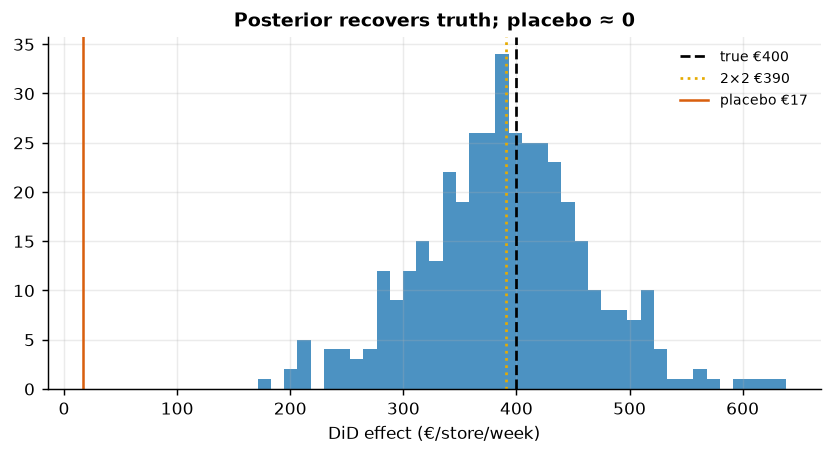

In [7]:
m = df.groupby(["group","post"])["revenue"].mean()
did_2x2 = (m[1,1]-m[1,0]) - (m[0,1]-m[0,0])
# placebo: pre-period only, fake launch at week 6
pre = df[df.t < LAUNCH].copy(); pre["fake_post"] = (pre.t >= 6).astype(int)
mp = pre.groupby(["group","fake_post"])["revenue"].mean()
placebo = (mp[1,1]-mp[1,0]) - (mp[0,1]-mp[0,0])
mp_sd = pre.groupby(["group","fake_post"])["revenue"].std()
mp_n  = pre.groupby(["group","fake_post"])["revenue"].count()
placebo_se = float(np.sqrt((mp_sd**2 / mp_n).sum()))   # SE of the placebo 2×2 = quadrature of the four cell-mean SEs
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.hist(impact, bins=40, color=plots.BLUE, alpha=0.85)
ax.axvline(true_effect, color="k", ls="--", label=f"true €{true_effect:.0f}")
ax.axvline(did_2x2, color=plots.GOLD, ls=":", label=f"2×2 €{did_2x2:.0f}")
ax.axvline(placebo, color=plots.ORANGE, lw=1.4, label=f"placebo €{placebo:.0f}")
ax.set_xlabel("DiD effect (€/store/week)"); ax.set_title("Posterior recovers truth; placebo ≈ 0"); ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
print(f"Bayesian €{impact.mean():.0f}  ·  2×2 €{did_2x2:.0f}  ·  true €{true_effect:.0f}  ·  "
      f"placebo (no real effect) €{placebo:.0f} ± SE €{placebo_se:.0f} — within sampling noise of zero")

### 5b · Placebo-in-group — a permutation null from the control stores

The time placebo asked "does our design manufacture effects out of **seasonality**?" The group placebo
asks the complementary question: "…out of **store-to-store noise**?" Together they bracket the two ways
a fake effect could arise in a panel. Take only the 20 control stores — the app never touched them, so
the true effect there is *exactly zero* — declare a random half "pseudo-treated", and run the very same
2×2 at the real launch week. Repeating over many random relabelings traces out the **permutation
null**: the full distribution of DiD estimates our pipeline produces *when nothing is going on*. Two
read-outs: **(i)** a permutation p-value — the share of relabelings whose placebo estimate beats the
real one in magnitude; **(ii)** an **assumption-light uncertainty cross-check** — the null's spread is
how far store noise alone can move this estimator, with no likelihood, no priors, no Gaussian anywhere.
File that second one away: compare it with the width of the Bayesian interval from Step 4 as you read
5c and 5d.

Permutation null: sd €14, largest |placebo DiD| €37. The real estimate €389 is ~29× the null's sd — store noise does not produce numbers like this: permutation p ≤ 0.012 (resolution floor 1/81).
Cross-check: noise alone moves this estimator by ~±€27 (2 sd — and a 10-vs-10 split is even noisier than the real 20-vs-20), yet the Bayesian interval above is ±€120 wide. An assumption-light hint that the 2×2 interval is conservative; 5c quantifies that, 5d fixes it.


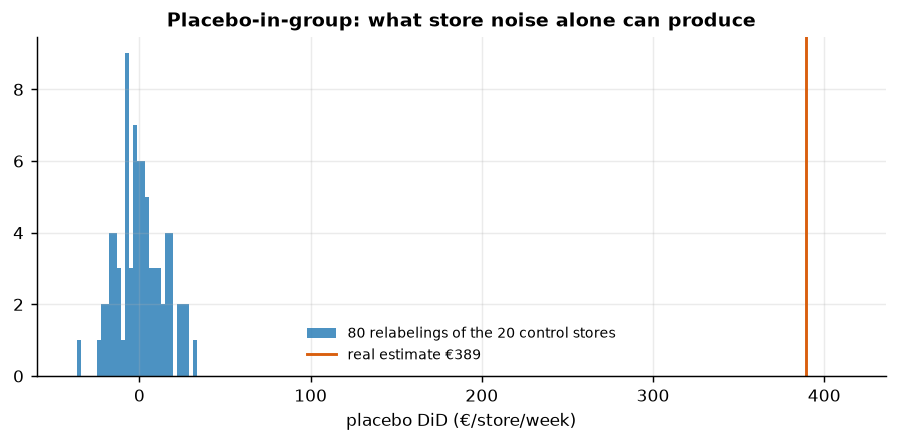

In [8]:
NPERM = 80 if FAST else 200
# On a balanced panel the 2×2 DiD equals the difference in mean per-store (post − pre) changes,
# so permuting store-level deltas IS permuting the 2×2 — one pandas pivot, then pure numpy.
ctrl_delta = (df[df.group == 0].pivot_table(index="unit", columns="post", values="revenue", aggfunc="mean")
                .pipe(lambda p: p[1] - p[0]).values)
rng_perm = np.random.default_rng(7); n_c = len(ctrl_delta)
perm = np.empty(NPERM)
for b in range(NPERM):
    fake = rng_perm.permutation(n_c) < n_c // 2
    perm[b] = ctrl_delta[fake].mean() - ctrl_delta[~fake].mean()
real_did = float(impact.mean())
p_perm = (1 + int((np.abs(perm) >= abs(real_did)).sum())) / (NPERM + 1)   # add-one permutation p
fig, ax = plt.subplots(figsize=(7.0, 3.5))
ax.hist(perm, bins=30, color=plots.BLUE, alpha=0.85, label=f"{NPERM} relabelings of the 20 control stores")
ax.axvline(real_did, color=plots.ORANGE, lw=1.6, label=f"real estimate €{real_did:.0f}")
ax.set_xlim(min(perm.min() * 1.3, -60), real_did * 1.12)
ax.set_xlabel("placebo DiD (€/store/week)"); ax.legend(frameon=False, fontsize=8)
ax.set_title("Placebo-in-group: what store noise alone can produce")
fig.tight_layout()
half_bayes = float(np.quantile(impact, 0.95) - np.quantile(impact, 0.05)) / 2
print(f"Permutation null: sd €{perm.std():.0f}, largest |placebo DiD| €{np.abs(perm).max():.0f}. The real estimate "
      f"€{real_did:.0f} is ~{abs(real_did)/perm.std():.0f}× the null's sd — store noise does not produce numbers like "
      f"this: permutation p ≤ {p_perm:.3f} (resolution floor 1/{NPERM + 1}).")
print(f"Cross-check: noise alone moves this estimator by ~±€{2 * perm.std():.0f} (2 sd — and a 10-vs-10 split is even "
      f"noisier than the real 20-vs-20), yet the Bayesian interval above is ±€{half_bayes:.0f} wide. An "
      f"assumption-light hint that the 2×2 interval is conservative; 5c quantifies that, 5d fixes it.")

### 5c · Recovery across many seeds — unbiased *and* calibrated?

A single sample can land a little off; the real test is whether the estimator is **centred on the truth over repeated samples** and whether its 90% interval **covers** the truth at the stated rate. We refit on many fresh samples (a small fast fit each; their sampler chatter is silenced below) and check both. Coverage can fail in **both** directions — an interval can be too *narrow* (overconfident) or too *wide* (conservative) — so beside counting hits we also compare the interval's width against the true seed-to-seed scatter.

DiD across 8 seeds: mean €403 (true €400)  bias +3  sd €11  ·  90% interval covers truth in 8/8 seeds.
But read 8/8 carefully: the headline interval's ±€120 half-width is ~11× the true seed-to-seed scatter (sd €11) — OVER-coverage, not perfect calibration. The 2×2 collapse leaves between-store baseline spread in the residual, so the interval is honest but conservative; downstream bounds (the break-even running cost, the stress-table probabilities) inherit that width — cautious, not sharp. (Store fixed effects / within-store differencing would tighten it.)


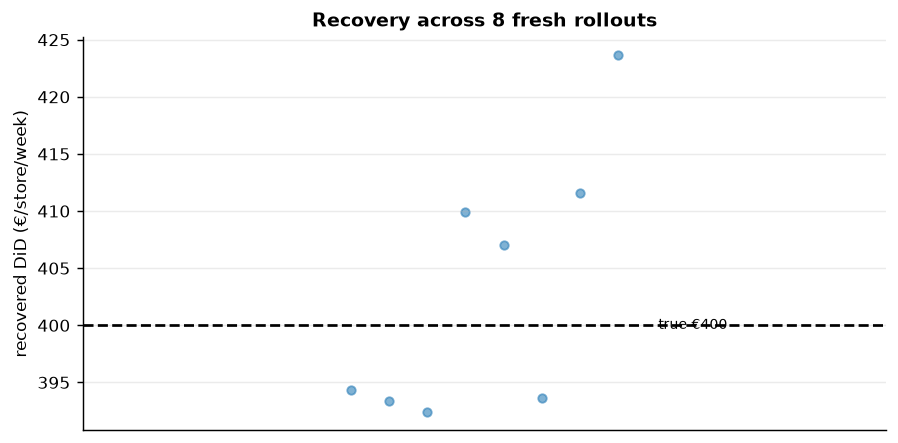

In [9]:
# --- Recovery across many seeds: does the DiD recover €400 and cover it? ---
NSEED = 8 if FAST else 20
import logging
_pml = logging.getLogger("pymc"); _pml_lvl = _pml.level   # silence the per-seed refits' sampler chatter
_pml.setLevel(logging.CRITICAL + 1)                       # (disclosed above; the same trick pymc's own
# _quiet_logging uses — the low-ESS notice is logged at ERROR level); restored at the end of the cell
pts = []; cov = 0
for sd in range(NSEED):
    d, te = dgp.did_rollout(n_stores=40, n_weeks=24, launch_week=LAUNCH, seed=100 + sd)
    ag = d.groupby(["unit", "group", "post_treatment"])["revenue"].mean().reset_index()
    ag["t"] = ag["post_treatment"].astype(int).astype(float)
    sv = ag["revenue"].std(); ag["revenue_z"] = (ag["revenue"] - ag["revenue"].mean()) / sv
    r = est.did(ag, formula="revenue_z ~ 1 + group*post_treatment", fast=True)
    im = np.asarray(r.causal_impact).ravel() * sv
    pts.append(im.mean()); lo, hi = np.quantile(im, [.05, .95]); cov += int(lo <= te <= hi)
pts = np.array(pts)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.scatter(np.linspace(-0.2, 0.2, NSEED), pts, s=22, color=plots.BLUE, alpha=0.6)
ax.axhline(true_effect, color="k", ls="--"); ax.text(0.26, true_effect, f"true €{true_effect:.0f}", fontsize=8, va="center")
ax.set_xticks([]); ax.set_xlim(-0.6, 0.6); ax.set_ylabel("recovered DiD (€/store/week)")
ax.set_title(f"Recovery across {NSEED} fresh rollouts"); fig.tight_layout()
print(f"DiD across {NSEED} seeds: mean €{pts.mean():.0f} (true €{true_effect:.0f})  bias {pts.mean()-true_effect:+.0f}  "
      f"sd €{pts.std():.0f}  ·  90% interval covers truth in {cov}/{NSEED} seeds.")
half = float(np.quantile(impact, 0.95) - np.quantile(impact, 0.05)) / 2
print(f"But read {cov}/{NSEED} carefully: the headline interval's ±€{half:.0f} half-width is "
      f"~{half/pts.std():.0f}× the true seed-to-seed scatter (sd €{pts.std():.0f}) — OVER-coverage, not perfect "
      f"calibration. The 2×2 collapse leaves between-store baseline spread in the residual, so the interval is "
      f"honest but conservative; downstream bounds (the break-even running cost, the stress-table probabilities) "
      f"inherit that width — cautious, not sharp. (Store fixed effects / within-store differencing would tighten it.)")
_pml.setLevel(_pml_lvl)

### 5d · Completing the diagnosis — within-store differencing

5c's verdict was "unbiased and covered, but roughly an order of magnitude too wide". The cause is
visible in the model spec of Step 4: the 2×2 pools stores, so the store baselines $\alpha_s$ (sd €150
by construction) sit in the residual $\sigma$ — the PPC in 4b showed exactly that fat $\sigma$. The
cure is the oldest trick in the fixed-effects book: **difference each store against itself**. Collapse
every store to a single number,

$$\Delta_s \;=\; \bar Y_{s,\text{post}} - \bar Y_{s,\text{pre}},$$

which removes $\alpha_s$ *exactly* (it is time-invariant, so it appears in both means and cancels)
while keeping the Bertrand–Duflo–Mullainathan two-period guard from Step 4. The DiD becomes a
one-coefficient comparison of store-level *changes*,

$$\Delta_s \;\sim\; \mathcal N\!\big(\gamma_0 + \gamma_1 D_s,\ \sigma_\Delta^2\big),\qquad
\widehat{\text{DiD}} \;=\; \gamma_1 \;=\; \bar\Delta_{D=1}-\bar\Delta_{D=0},$$

with $\gamma_0$ the control stores' mean change (the seasonal tide) and $\sigma_\Delta$ containing only
averaged week-level noise, no store baselines. Same estimand, same point estimate — radically smaller
residual. It's a ten-line PyMC model with weak priors on the standardized scale. And the non-negotiable
check: a *tighter* interval is progress only if coverage survives, so we re-run 5c's seed loop on this
estimator — a tightening that broke coverage would be overconfidence wearing a fix's clothes.

Within-store DiD €390 (true €400) · 90% interval [€370, €412] — half-width €21
  vs the pooled 2×2's €120 (~6× tighter)
  convergence: max r-hat 1.000 - min ESS 473 - divergences 0
Seed loop (8 fresh rollouts): mean €403, seed-to-seed sd €9, coverage 6/8.
  The 90%-interval half-width (≈€17) is ~1.8× the seed scatter,
  where a calibrated 90% interval sits at ≈1.6× (the pooled 2×2 was at ~11×):
  -> tight AND calibrated
  (with only 8 seeds the hit count is itself binomially noisy).
Decision preview: the running cost the app clears with 95% posterior probability
  moves from ~€275 (pooled 2×2) to ~€370/store/week (within-store posterior).


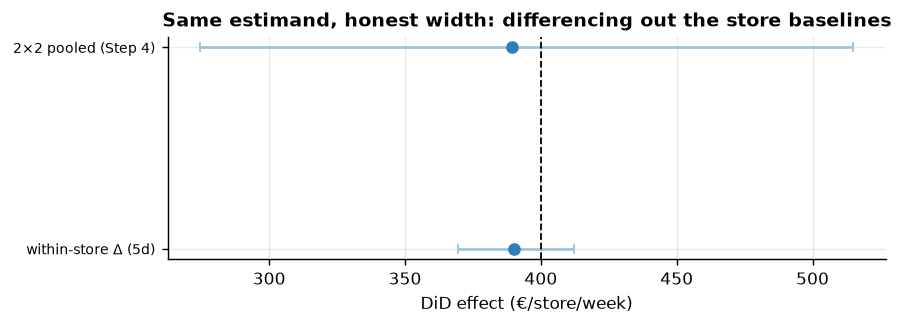

In [10]:
# Within-store differencing: one Delta per store, then a 2-parameter Bayesian comparison of changes.
import logging, pymc as pm
_pml = logging.getLogger("pymc"); _pml_lvl2 = _pml.level
_pml.setLevel(logging.CRITICAL + 1)                      # silence sampler chatter (SamplerWarnings log at ERROR)

def fit_delta(frame, fast):
    """Delta_s ~ N(g0 + g1*D_s, sigma^2), fitted on the standardized scale; returns euro-scale g1 draws."""
    ds = frame["delta"].std()
    with pm.Model():
        g0 = pm.Normal("g0", 0, 5); g1 = pm.Normal("g1", 0, 5)
        sig = pm.HalfNormal("sigma", 1)
        pm.Normal("dz", g0 + g1 * frame["group"].values, sig, observed=frame["delta"].values / ds)
        idata = pm.sample(draws=400 if fast else 1000, tune=400 if fast else 1000,
                          chains=2 if fast else 4, progressbar=False, compute_convergence_checks=False)
    return idata.posterior["g1"].values.ravel() * ds, idata

def delta_frame(frame):
    p = frame.pivot_table(index=["unit", "group"], columns="post", values="revenue", aggfunc="mean").reset_index()
    p["delta"] = p[1] - p[0]
    return p

impact_fe, idata_fe = fit_delta(delta_frame(df), fast=FAST)
cov_fe = 0; pts_fe = []; hw_fe = []
for s_ in range(NSEED):                                   # same seeds as 5c, same loop, tighter estimator
    d_, te_ = dgp.did_rollout(n_stores=40, n_weeks=24, launch_week=LAUNCH, seed=100 + s_)
    im_, _ = fit_delta(delta_frame(d_), fast=True)
    lo_, hi_ = np.quantile(im_, [.05, .95])
    pts_fe.append(im_.mean()); hw_fe.append((hi_ - lo_) / 2); cov_fe += int(lo_ <= te_ <= hi_)
pts_fe = np.array(pts_fe)
_pml.setLevel(_pml_lvl2)
q_w = np.quantile(impact, [.05, .95]); q_f = np.quantile(impact_fe, [.05, .95])
half_w, half_f = (q_w[1] - q_w[0]) / 2, (q_f[1] - q_f[0]) / 2
fig, ax = plt.subplots(figsize=(7.0, 2.6))
plots.forest_plot(ax, ["2×2 pooled (Step 4)", "within-store Δ (5d)"],
                  [impact.mean(), impact_fe.mean()], [q_w[0], q_f[0]], [q_w[1], q_f[1]],
                  ref=true_effect, xlabel="DiD effect (€/store/week)",
                  title="Same estimand, honest width: differencing out the store baselines")
fig.tight_layout()
print(f"Within-store DiD €{impact_fe.mean():.0f} (true €{true_effect:.0f}) · 90% interval "
      f"[€{q_f[0]:.0f}, €{q_f[1]:.0f}] — half-width €{half_f:.0f}\n"
      f"  vs the pooled 2×2's €{half_w:.0f} (~{half_w / half_f:.0f}× tighter)\n"
      f"  convergence: {est.convergence_report(idata_fe)['summary']}")
cal = "tight AND calibrated" if cov_fe / NSEED >= 0.75 else "tight but under-covering — investigate before trusting"
print(f"Seed loop ({NSEED} fresh rollouts): mean €{pts_fe.mean():.0f}, seed-to-seed sd €{pts_fe.std():.0f}, "
      f"coverage {cov_fe}/{NSEED}.\n"
      f"  The 90%-interval half-width (≈€{np.mean(hw_fe):.0f}) is ~{np.mean(hw_fe) / pts_fe.std():.1f}× "
      f"the seed scatter,\n"
      f"  where a calibrated 90% interval sits at ≈1.6× (the pooled 2×2 was at ~11×):\n"
      f"  -> {cal}\n"
      f"  (with only {NSEED} seeds the hit count is itself binomially noisy).")
print(f"Decision preview: the running cost the app clears with 95% posterior probability\n"
      f"  moves from ~€{q_w[0]:.0f} (pooled 2×2) to ~€{q_f[0]:.0f}/store/week (within-store posterior).")

**Read-out.** Same point estimate, an interval several times tighter, and — the part that makes the
tightening legitimate — the seed loop's hit count (printed above) stays statistically consistent with the nominal 90% once you
account for binomial noise on a handful of seeds: the width we removed was redundancy, not protection. Notice that three *independent* witnesses now agree on the
honest uncertainty scale: the permutation null's spread (5b), the seed-to-seed scatter (5c), and the
within-store posterior (5d). Step 6 below prices the decision with the **conservative** Step-4
posterior on purpose — a rollout case that survives the wide interval is robust — and the break-even
print above shows how much sharper the same case becomes once the analysis earns its precision.

## 6 · Decide, in euros — the rollout case

Under parallel trends the DiD number is the **ATT — the effect on the pilot stores.** Rolling the app out to
all 500 assumes the other 480 respond the same way, which chains rarely guarantee (pilot sites aren't picked
at random). So alongside the headline projection we **stress it two ways**: a **transfer discount** (what if
the non-pilot stores realise only 75% or 50% of the pilot lift?) and a **cost sweep** (how high can the app's
running cost climb before the call flips?). The table below is P(app pays) across both — robust at full
transfer, but a *pilot-further* call under aggressive discounting and higher running costs. (The €120 running cost is an illustrative all-in figure — licences + operations per store-week; one-time build/rollout capex is deliberately outside the per-week economics.)

In [11]:
N_STORES, WEEKS, APP_COST = 500, 52, 120.0   # APP_COST: illustrative all-in running cost (licence+ops)/store-week
                                             # — swap in your vendor quote; one-time build capex is out of scope
net = impact - APP_COST
annual = net * N_STORES * WEEKS
p_worth = (net > 0).mean()
print(f"Base case (APP_COST €{APP_COST:.0f}, full pilot lift across {N_STORES} stores):")
print(f"  net €{net.mean():.0f}/store/week  ·  annual value €{annual.mean():,.0f} "
      f"[90% €{np.quantile(annual,0.05):,.0f}, €{np.quantile(annual,0.95):,.0f}]\n"
      f"  P(app pays) {p_worth:.2f} → "
      + ("ROLL OUT" if p_worth > 0.9 else "pilot further"))
be95 = np.quantile(impact, 0.05)
print(f"  break-even: the app clears its cost with 95% posterior probability\n"
      f"  while the running cost stays below ~€{be95:.0f}/store/week.")

# Stress the roll-out two ways: (a) TRANSFER discount — the 480 non-pilot stores may realize less than the
# pilot ATT; (b) a COST sweep — how high can the running cost climb before the roll-out call flips?
transfers = [(1.00, "100% (as pilot)"), (0.75, "75%"), (0.50, "50%")]
costgrid = [80, 120, 200, 300]
print("\nP(app pays) by transfer share (rows) and running cost in €/store/week (cols):")
print("  transfer \\ cost" + "".join(f"{c:>7}" for c in costgrid))
for tr, lab in transfers:
    eff = impact * tr
    print(f"  {lab:<15}" + "".join(f"{(eff > c).mean():>7.2f}" for c in costgrid))
print("\nMost the roll-out can pay per store/week and still clear cost")
print("at 90% posterior confidence:")
for tr, lab in transfers:
    print(f"  at {lab:<16} up to ~€{np.quantile(impact * tr, 0.10):.0f}")

Base case (APP_COST €120, full pilot lift across 500 stores):
  net €269/store/week  ·  annual value €7,002,587 [90% €4,021,073, €10,270,170]
  P(app pays) 1.00 → ROLL OUT
  break-even: the app clears its cost with 95% posterior probability
  while the running cost stays below ~€275/store/week.

P(app pays) by transfer share (rows) and running cost in €/store/week (cols):
  transfer \ cost     80    120    200    300
  100% (as pilot)   1.00   1.00   0.99   0.89
  75%               1.00   1.00   0.95   0.43
  50%               1.00   0.97   0.43   0.01

Most the roll-out can pay per store/week and still clear cost
at 90% posterior confidence:
  at 100% (as pilot)  up to ~€296
  at 75%              up to ~€222
  at 50%              up to ~€148


**Read-out.** At face value the base case is emphatic: ≈ €273/store/week of net value over the
€120 running cost, ≈ €7.1M of annual value across the 500-store chain, P(app pays) ≈ 1.00 →
**ROLL OUT**. The stress table is where the real decision lives, and it splits along one axis:
reading *across* a row, the call barely moves with the running cost while the transfer assumption
holds; reading *down* a column, it degrades fast as the assumed transfer falls — at 50% transfer
the €200 cost cell is a coin flip (0.46) and €300 is a clear no (0.00). Since pilot stores are
rarely representative of the chain, the honest headline is the last block: the rollout can pay
**up to ≈ €300/store/week if the whole chain responds like the pilot, but only ≈ €150 if half the
lift transfers** — that range, not the base-case €7.1M, is the number to hold against a vendor
quote. If the quote lands inside it, the cheap de-risking move is a second pilot wave in
deliberately *non*-pilot-like stores to measure the transfer share directly.

## 7 · Caveats — the assumptions under stress, live

**Parallel trends is the whole ballgame** and untestable post-launch; a diverging pre-trend kills the
design (move to synthetic control, notebook 07). **No spillover (SUTVA):** the app must not move
revenue in *other* stores — if app-holders defect from nearby control stores, the control trend dips
and DiD *overstates* the lift; if pilot buzz lifts the whole chain, it understates. No within-sample
diagnostic can see either; it is a market-structure judgment (flag pilot stores that share a catchment
with controls). Beyond these, two traps deserve a live demonstration each.

**Trap 1 — anticipation (Assumption 2, broken on purpose).** Suppose the pilot stores start behaving
differently *before* week 12 — pre-launch promo buzz, staff trained early, customers holding back
purchases until the app's perks arrive — so the lift effectively starts two weeks early. The "pre"
baseline is then contaminated with effect, and DiD subtracts part of the app from itself. We rerun the
simulation with exactly that change and redraw Step 3's event study:

The k=−2 and k=−1 leads sit at €364 and €340 — far outside their 90% bands (4 of 12 pre-launch leads exclude 0, vs ~1 expected by chance).
Naive 2×2: €324 vs true €400 — bias €-76, ≈ −2/12 of the effect (≈ €67): the 2 contaminated pre-weeks inflate the treated baseline by that much.
Fix — drop the contaminated window from the pre-period: €394. (Or define 'treatment' at the ANNOUNCEMENT date rather than the launch date.)


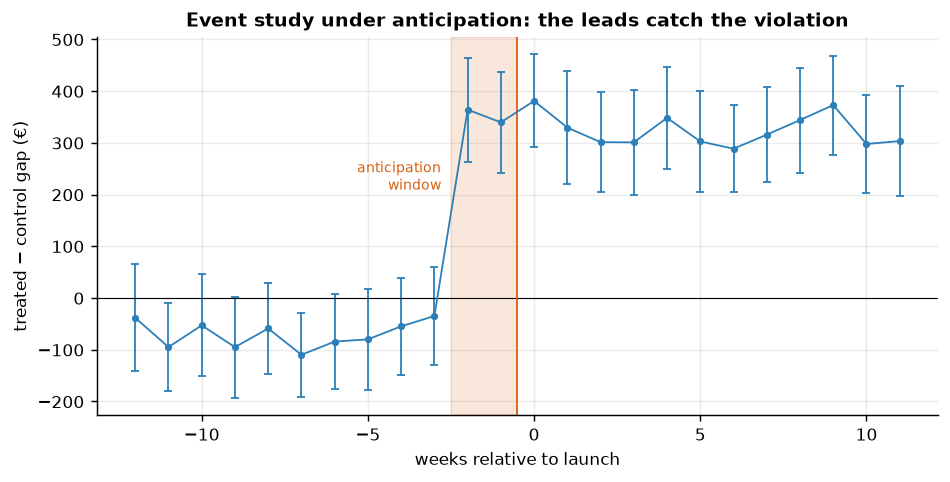

In [12]:
# Same DGP as Step 2, except the lift starts ANT weeks BEFORE the official launch (anticipation).
ANT = 2
rng_a = np.random.default_rng(SEED)
fx_a = rng_a.normal(1000, 150, 40)
tr_a = np.zeros(40, dtype=bool); tr_a[:20] = True; rng_a.shuffle(tr_a)
season_a = 60 * np.sin(2 * np.pi * np.arange(24) / 12)
rows_a = []
for s in range(40):
    eff = TRUE * (np.arange(24) >= LAUNCH - ANT) * tr_a[s]        # <- effect from week 10, not 12
    rows_a.append(pd.DataFrame({"unit": s, "t": np.arange(24), "group": int(tr_a[s]),
                                "post": (np.arange(24) >= LAUNCH).astype(int),
                                "revenue": fx_a[s] + season_a + eff + rng_a.normal(0, 80, 24)}))
da = pd.concat(rows_a, ignore_index=True)
piv_a = da.pivot_table(index="t", columns="group", values="revenue", aggfunc="mean")
sd_a  = da.pivot_table(index="t", columns="group", values="revenue", aggfunc="std")
n_a   = da.pivot_table(index="t", columns="group", values="revenue", aggfunc="count")
gap_a = piv_a[1] - piv_a[0]; se_a = np.sqrt(sd_a[1]**2 / n_a[1] + sd_a[0]**2 / n_a[0])
pre_a = gap_a.index < LAUNCH
gapc_a = gap_a - gap_a[pre_a].mean()
fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.errorbar(gapc_a.index - LAUNCH, gapc_a.values, yerr=1.645 * se_a.values,
            color=plots.BLUE, marker="o", lw=1.0, ms=3, capsize=2)
ax.axvspan(-ANT - 0.5, -0.5, color=plots.ORANGE, alpha=0.15)
ax.text(-ANT - 0.8, gapc_a.max() * 0.55, "anticipation\nwindow", ha="right", fontsize=8, color=plots.ORANGE)
ax.axhline(0, color="k", lw=0.6); ax.axvline(-0.5, color=plots.ORANGE, lw=1)
ax.set_xlabel("weeks relative to launch"); ax.set_ylabel("treated − control gap (€)")
ax.set_title("Event study under anticipation: the leads catch the violation")
fig.tight_layout()
m_a = da.groupby(["group", "post"])["revenue"].mean()
did_a = (m_a[1, 1] - m_a[1, 0]) - (m_a[0, 1] - m_a[0, 0])
clean = da[(da.t < LAUNCH - ANT) | (da.t >= LAUNCH)]              # drop the contaminated pre-weeks
m_f = clean.groupby(["group", "post"])["revenue"].mean()
did_f = (m_f[1, 1] - m_f[1, 0]) - (m_f[0, 1] - m_f[0, 0])
n_bad = int((gapc_a[pre_a].abs() > 1.645 * se_a[pre_a]).sum())
print(f"The k=−2 and k=−1 leads sit at €{gapc_a.loc[LAUNCH - 2]:.0f} and €{gapc_a.loc[LAUNCH - 1]:.0f} — far outside "
      f"their 90% bands ({n_bad} of {int(pre_a.sum())} pre-launch leads exclude 0, vs ~1 expected by chance).")
print(f"Naive 2×2: €{did_a:.0f} vs true €{TRUE:.0f} — bias €{did_a - TRUE:+.0f}, ≈ −{ANT}/{LAUNCH} of the effect "
      f"(≈ €{TRUE * ANT / LAUNCH:.0f}): the {ANT} contaminated pre-weeks inflate the treated baseline by that much.")
print(f"Fix — drop the contaminated window from the pre-period: €{did_f:.0f}. "
      f"(Or define 'treatment' at the ANNOUNCEMENT date rather than the launch date.)")

**Read-out.** This is what a violated lead looks like — compare Step 3's clean version. The last two
leads jump out of their bands two weeks *before* the official launch, and because centred leads must
average zero by construction, the contamination also drags the *other* leads slightly negative: the
tell is a broken, tilted pre-period, not just two high dots. The flat-leads check is no formality — it
just caught a violation that quietly ate roughly a sixth of the measured effect. The remedies are cheap
once you *see* it: drop the anticipation window from the pre-period (done above — the estimate snaps
back to truth within noise) or date the treatment at *announcement* rather than launch. What the leads
still cannot do is certify PT itself: a time-varying, group-specific shock arriving exactly at launch
remains invisible.

**Trap 2 — staggered adoption.** Real chains rarely launch everywhere at once. With multiple adoption
dates the workhorse regression becomes static **two-way fixed effects (TWFE)**:

$$Y_{st}\;=\;\alpha_s+\lambda_t+\beta^{\text{TWFE}}\,D_{st}+\varepsilon_{st},\qquad D_{st}=\mathbf 1[t\ge g_s],$$

where $g_s$ is store $s$'s adoption week. **Goodman-Bacon (2021):** $\hat\beta^{\text{TWFE}}$ is a
variance-weighted average of **every pairwise 2×2 DiD** the panel contains — early-vs-late,
late-vs-early, treated-vs-untreated — *including* "forbidden comparisons" that use **already-treated**
cohorts as controls. When effects grow with time since adoption, those comparisons can receive
**negative weights**, so TWFE can land far from every true effect even though each one is positive.
Watch it happen:

Naive TWFE €177 vs true average post-treatment effect €400 — bias -223. Use Callaway–Sant'Anna / Sun–Abraham for staggered rollouts.


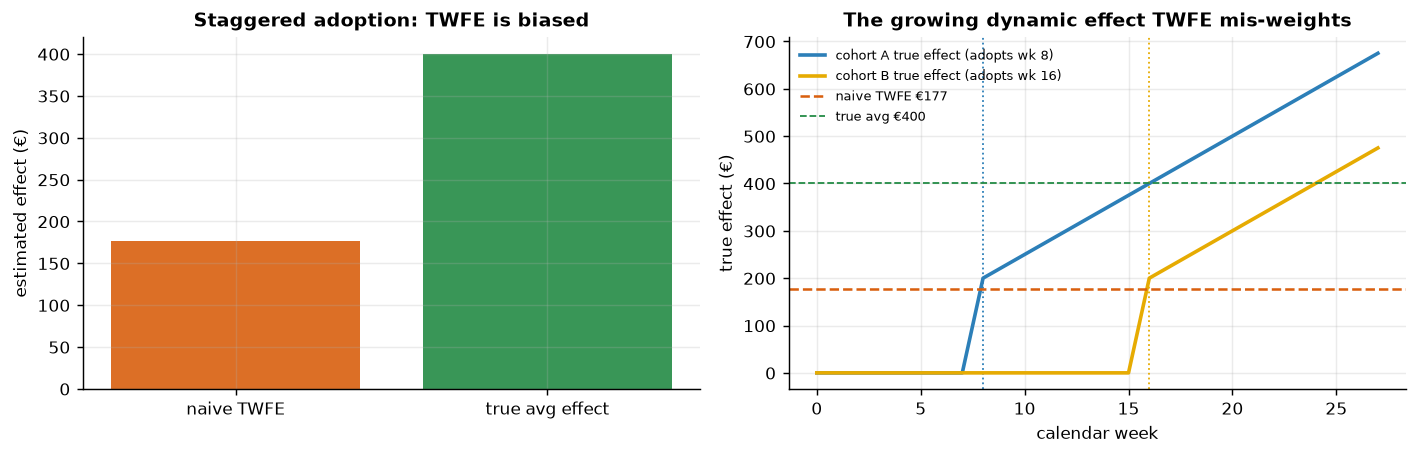

In [13]:
# staggered rollout: cohort A treated at week 8, cohort B at week 16, with a GROWING true effect
rng = np.random.default_rng(1); NS, NW = 60, 28
rows = []
for s in range(NS):
    cohort = "A" if s < NS//2 else "B"; g = 8 if cohort=="A" else 16
    base = rng.normal(1000, 120); season = 60*np.sin(2*np.pi*np.arange(NW)/12)
    # dynamic effect that GROWS after adoption (this is what breaks naive TWFE)
    te = np.where(np.arange(NW) >= g, 200 + 25*(np.arange(NW)-g), 0.0)
    rev = base + season + te + rng.normal(0, 60, NW)
    for t in range(NW):
        rows.append({"unit": s, "cohort": cohort, "t": t, "post": int(t>=g), "rev": rev[t], "true_te": te[t]})
sd = pd.DataFrame(rows)
# naive TWFE (single post dummy) vs the true average post-treatment effect
Xd = pd.get_dummies(sd["unit"], prefix="u").astype(float); Xt = pd.get_dummies(sd["t"], prefix="t").astype(float)
D = np.column_stack([np.ones(len(sd)), sd["post"].values, Xd.values[:,1:], Xt.values[:,1:]])
twfe = np.linalg.lstsq(D, sd["rev"].values, rcond=None)[0][1]
true_avg = sd.loc[sd.post==1, "true_te"].mean()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(["naive TWFE","true avg effect"], [twfe, true_avg], color=[plots.ORANGE, plots.GREEN], alpha=0.9)
ax[0].set_ylabel("estimated effect (€)"); ax[0].set_title("Staggered adoption: TWFE is biased")
# WHY it's biased: the true effect GROWS after each cohort adopts (weeks 8 and 16), so collapsing it
# to one post dummy — while using already-treated cohort A as a control for B — badly mis-weights it.
for _coh, _col in [("A", plots.BLUE), ("B", plots.GOLD)]:
    _g = 8 if _coh == "A" else 16
    _te = sd[sd.cohort == _coh].groupby("t")["true_te"].mean()
    ax[1].plot(_te.index, _te.values, color=_col, lw=2, label=f"cohort {_coh} true effect (adopts wk {_g})")
    ax[1].axvline(_g, color=_col, ls=":", lw=1)
ax[1].axhline(twfe, color=plots.ORANGE, ls="--", lw=1.4, label=f"naive TWFE €{twfe:.0f}")
ax[1].axhline(true_avg, color=plots.GREEN, ls="--", lw=1.0, label=f"true avg €{true_avg:.0f}")
ax[1].set_xlabel("calendar week"); ax[1].set_ylabel("true effect (€)")
ax[1].set_title("The growing dynamic effect TWFE mis-weights"); ax[1].legend(frameon=False, fontsize=7)
fig.tight_layout()
print(f"Naive TWFE €{twfe:.0f} vs true average post-treatment effect €{true_avg:.0f} — "
      f"bias {twfe-true_avg:+.0f}. Use Callaway–Sant'Anna / Sun–Abraham for staggered rollouts.")

**Why the bias is downward here — and the cure.** Cohort A adopts at week 8 and its effect keeps
*growing*; when B adopts at week 16, part of TWFE's estimate compares B against already-treated A — a
"control" whose revenue is still rising with A's growing effect. B's lift is measured against that
rising counterfactual and shrunk, and the growing tail of A's effect looks like a calendar trend that
the week effects $\lambda_t$ partially absorb. Net: the largest true effects get the smallest (even
negative) weights, and the estimate lands *below every single true post-adoption effect in the panel*.

The modern fix — **Callaway & Sant'Anna (2021)** — is a discipline, not a trick: *never use the
already-treated as controls*. Estimate one clean 2×2 per cohort $g$ and week $t$, anchored at the
cohort's last untreated week $g-1$, using only stores **not yet treated** at $t$ as controls:

$$\widehat{\text{ATT}}(g,t)\;=\;\big[\bar Y_{g,t}-\bar Y_{g,\,g-1}\big]\;-\;\big[\bar Y_{\mathcal C(t),\,t}-\bar Y_{\mathcal C(t),\,g-1}\big],\qquad \mathcal C(t)=\{s:\ g_s>t\},$$

then aggregate the cells (here a simple average — cohorts are equal-sized). One **design lesson** falls
straight out of the formula: in the two-cohort world above, $\mathcal C(t)$ is *empty* from week 16
onward — once everyone is treated there are no clean controls left and $\text{ATT}(g,t)$ simply does
not exist. Real rollouts should **keep a never-treated holdout** for exactly this reason. So we
regenerate the same growing-effect world with a third cohort C (20 stores, never treated) and run both
estimators on it — the ~15-line loop below is the entire method.

A never-treated holdout in the panel helps TWFE (€321 here vs €177 without one, above) but does NOT fix it — the forbidden A-as-control-for-B comparisons are still inside the average.
Hand-rolled Callaway–Sant'Anna: €405 vs true average €400 — within store-noise of the truth, from 32 clean (g,t) cells; the left panel shows the cells tracking the growing effect itself.
Production tools: R `did` (Callaway–Sant'Anna) or `fixest::sunab` (Sun–Abraham); Python `pyfixest`, `differences`.


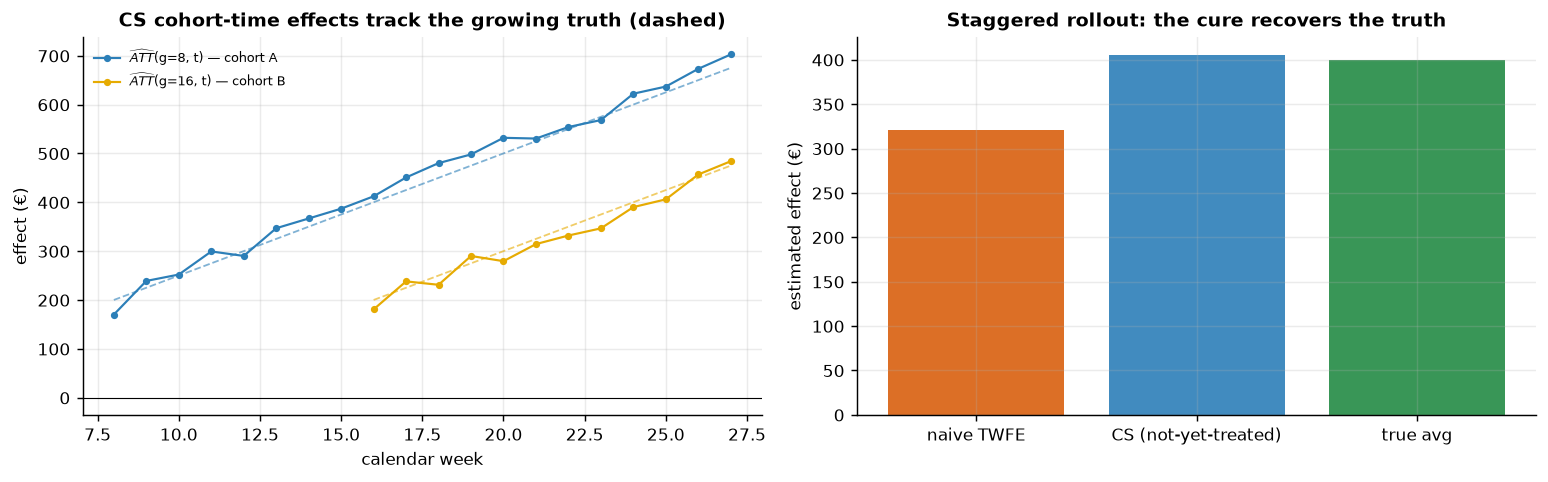

In [14]:
# Same growing-effect world + a never-treated cohort C, then: naive TWFE vs hand-rolled Callaway–Sant'Anna.
rng3 = np.random.default_rng(2); NW3 = 28
rows3 = []
for s in range(60):
    coh = "A" if s < 20 else ("B" if s < 40 else "C")
    g_s = {"A": 8, "B": 16, "C": 10**9}[coh]                     # cohort C: never treated ("adopts at infinity")
    base3 = rng3.normal(1000, 120); season3 = 60 * np.sin(2 * np.pi * np.arange(NW3) / 12)
    te3 = np.where(np.arange(NW3) >= g_s, 200 + 25 * (np.arange(NW3) - g_s), 0.0)
    rev3 = base3 + season3 + te3 + rng3.normal(0, 60, NW3)
    for t in range(NW3):
        rows3.append({"unit": s, "g": g_s, "t": t, "post": int(t >= g_s), "rev": rev3[t], "true_te": te3[t]})
s3 = pd.DataFrame(rows3)
# naive TWFE on the 3-cohort panel (the never-treated cohort now anchors the week effects)
X_u = pd.get_dummies(s3["unit"]).astype(float); X_t = pd.get_dummies(s3["t"]).astype(float)
D3 = np.column_stack([np.ones(len(s3)), s3["post"].values, X_u.values[:, 1:], X_t.values[:, 1:]])
twfe3 = np.linalg.lstsq(D3, s3["rev"].values, rcond=None)[0][1]
# Callaway–Sant'Anna by hand: one clean 2×2 per (cohort g, week t), controls = not-yet-treated at t
ym = s3.groupby(["g", "t"])["rev"].mean()
att = {}
for g in (8, 16):
    for t in range(g, NW3):
        ctrl3 = s3[s3.g > t]                                     # not-yet-treated at t (B early on, C always)
        att[(g, t)] = (ym[g, t] - ym[g, g - 1]) - (ctrl3[ctrl3.t == t]["rev"].mean()
                                                   - ctrl3[ctrl3.t == g - 1]["rev"].mean())
att = pd.Series(att); cs_avg = float(att.mean())
true_avg3 = s3.loc[s3.post == 1, "true_te"].mean()
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for g, col, lab in [(8, plots.BLUE, "A"), (16, plots.GOLD, "B")]:
    tt = np.arange(g, NW3)
    ax[0].plot(tt, att.loc[g].values, "o-", color=col, ms=3, lw=1.2, label=f"$\\widehat{{ATT}}$(g={g}, t) — cohort {lab}")
    ax[0].plot(tt, 200 + 25 * (tt - g), ls="--", color=col, lw=1, alpha=0.6)
ax[0].axhline(0, color="k", lw=0.6); ax[0].set_xlabel("calendar week"); ax[0].set_ylabel("effect (€)")
ax[0].set_title("CS cohort-time effects track the growing truth (dashed)"); ax[0].legend(frameon=False, fontsize=7)
ax[1].bar(["naive TWFE", "CS (not-yet-treated)", "true avg"], [twfe3, cs_avg, true_avg3],
          color=[plots.ORANGE, plots.BLUE, plots.GREEN], alpha=0.9)
ax[1].set_ylabel("estimated effect (€)"); ax[1].set_title("Staggered rollout: the cure recovers the truth")
fig.tight_layout()
print(f"A never-treated holdout in the panel helps TWFE (€{twfe3:.0f} here vs €{twfe:.0f} without one, above) but "
      f"does NOT fix it — the forbidden A-as-control-for-B comparisons are still inside the average.")
print(f"Hand-rolled Callaway–Sant'Anna: €{cs_avg:.0f} vs true average €{true_avg3:.0f} — within store-noise of the "
      f"truth, from {len(att)} clean (g,t) cells; the left panel shows the cells tracking the growing effect itself.")
print("Production tools: R `did` (Callaway–Sant'Anna) or `fixest::sunab` (Sun–Abraham); Python `pyfixest`, `differences`.")

## 8 · What we tell the CMO

> **Finding.** The loyalty app lifted pilot-store revenue by ≈ €400/store/week net of the seasonal tide
> (Step 4's posterior — and the simulation's planted truth is €400, recovered). The estimate survived
> every falsification we threw at it: flat pre-launch leads (Step 3), a fake launch date (≈ 0, Step 5), a
> permutation of fake treated stores (the real estimate sits far outside anything store noise produced,
> 5b), a posterior predictive check (4b), and a multi-seed recovery loop (5c) — with the within-store
> design (5d) confirming the same point estimate under a far tighter, *calibrated* interval.
>
> **Decision.** At the €120/store/week running cost the base case says **ROLL OUT** (P(app pays) ≈ 1).
> But the DiD estimand is the **ATT — the effect on the pilot stores** — and the non-pilot stores need
> not respond identically, so the honest headline is the stress table's break-even band: the rollout
> clears its cost up to roughly **€300/store/week if the chain responds like the pilot, only ≈ €150 if
> half the lift transfers**. Hold the vendor quote against that band, not against the base-case annual
> € figure.
>
> **Recommended action.** Phase the rollout, with wave 2 in deliberately *non-pilot-like* stores to
> measure the transfer share directly — and keep a small **never-treated holdout** to the very end:
> Step 7 showed clean controls are what keep every later wave measurable, cheap insurance an
> all-at-once rollout destroys.
>
> **Watch-list** (the assumptions that carry everything): **parallel trends** — monitor the leads every
> wave; **no anticipation** — date effects from *announcement* and drop contaminated pre-weeks (the
> leads catch it, as demonstrated); **no cross-store spillover** — flag pilot stores sharing a
> catchment with controls; and **never evaluate a staggered rollout with a single post dummy** — use
> cohort-time effects with not-yet-treated controls (Callaway–Sant'Anna), or growing effects will bias
> the answer just as TWFE's did above.

**Method summary.** DiD buys identification with two assumptions (PT + NA) and one subtraction; the
event-study leads probe NA and make PT credible, but nothing certifies PT post-launch. The Bayesian
layer is ordinary regression — the craft is in the *scale* (default priors vs euro data, Step 4), in
the *collapse* that guards against serial correlation (BDM), and in knowing which residual your
interval is paying for (5b–5d). **On real data:** notebook 07b (geo-lift on a real Google
geo-experiment) is this design's nearest real-data sibling in the cookbook, and Card & Krueger (1994)
remains the classic public DiD panel to practice on.